# Applied Machine Learning - Homework 1
## Fundamentals: Loss Functions, Neural Networks & Basic ML Framework

### Learning Objectives
By completing this homework, you will:
1. Implement and compare different loss functions (MSE, MAE)
2. Build a simple neural network from scratch using NumPy
3. Understand forward and backward propagation
4. Implement basic gradient descent optimization
1

In [1]:
# Essential imports for the homework
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import seaborn as sns
from sklearn.datasets import make_classification, make_regression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings('ignore')

# Set random seed for reproducibility
np.random.seed(42)

# Configure plotting
plt.style.use('default')
sns.set_palette("husl")
print("✅ All imports successful!")
print(f"NumPy version: {np.__version__}")

✅ All imports successful!
NumPy version: 2.4.2


---
# Part 1: Loss Functions Implementation and Analysis

In this section, you'll implement various loss functions and understand their mathematical properties and use cases.

In [4]:
class LossFunctions:
    """Collection of loss functions for machine learning."""
    
    @staticmethod
    def mean_squared_error(y_true, y_pred):
        """
        Calculate Mean Squared Error (MSE).
        
        Args:
            y_true: True target values
            y_pred: Predicted values
            
        Returns:
            MSE loss value
        """
        # TODO: Implement MSE formula: (1/n) * Σ(y_true - y_pred)²
        # Hint: Use np.mean() and np.square()
        return np.mean(np.square(y_true - y_pred))
    
    @staticmethod
    def mean_absolute_error(y_true, y_pred):
        """
        Calculate Mean Absolute Error (MAE).
        
        Args:
            y_true: True target values
            y_pred: Predicted values
            
        Returns:
            MAE loss value
        """
        # TODO: Implement MAE formula: (1/n) * Σ|y_true - y_pred|
        # Hint: Use np.mean() and np.abs()
        return np.mean(np.abs(y_true - y_pred))      ## Replaced pass with implementation

# Test the loss functions with sample data
def test_loss_functions():
    """Test function to verify loss function implementations."""
    print("Testing Loss Functions...")
    
    # Test data for regression
    y_true_reg = np.array([2.5, 1.8, 3.2, 0.9, 2.1])
    y_pred_reg = np.array([2.3, 1.9, 3.0, 1.1, 2.0])
    
    # Test MSE (should work since it's implemented)
    mse = LossFunctions.mean_squared_error(y_true_reg, y_pred_reg)
    print(f"✅ MSE: {mse:.4f}")
    
    # Test MAE (students need to implement)
    try:
        mae = LossFunctions.mean_absolute_error(y_true_reg, y_pred_reg)
        if mae is not None:
            print(f"✅ MAE: {mae:.4f}")
        else:
            print("❌ MAE: Not implemented yet")
    except:
        print("❌ MAE: Not implemented yet")

# Run the test
test_loss_functions()

Testing Loss Functions...
✅ MSE: 0.0280
✅ MAE: 0.1600


### Task 1.1: Visualize Loss Function Behavior

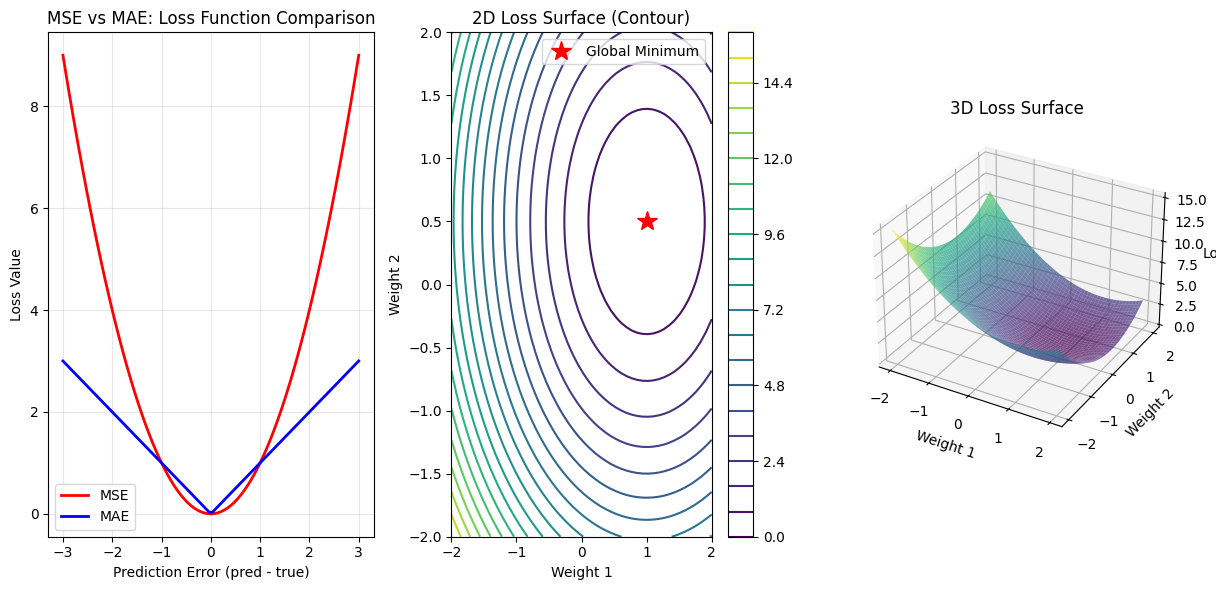

In [7]:
def visualize_loss_functions():
    """Visualize how different loss functions behave with varying prediction errors."""
    
    # Create range of prediction errors
    true_value = 0
    predictions = np.linspace(-3, 3, 100)
    
    # Calculate losses for each prediction
    mse_losses = [LossFunctions.mean_squared_error(np.array([true_value]), np.array([pred])) for pred in predictions]
    
    # TODO: Calculate MAE losses for each prediction
    # Hint: Use list comprehension similar to MSE above
    mae_losses = [LossFunctions.mean_absolute_error(np.array([true_value]), np.array([pred])) for pred in predictions]
    
    # Create the visualization
    plt.figure(figsize=(12, 6))
    
    # Plot MSE vs MAE comparison
    plt.subplot(1, 3, 1)
    plt.plot(predictions, mse_losses, label='MSE', linewidth=2, color='red')
    plt.plot(predictions, mae_losses, label='MAE', linewidth=2, color='blue')
    plt.xlabel('Prediction Error (pred - true)')
    plt.ylabel('Loss Value')
    plt.title('MSE vs MAE: Loss Function Comparison')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    # Loss surface visualization for 2D case
    plt.subplot(1, 3, 2)
    # Create a simple 2D loss surface
    w1_range = np.linspace(-2, 2, 50)
    w2_range = np.linspace(-2, 2, 50)
    W1, W2 = np.meshgrid(w1_range, w2_range)
    
    # Simple quadratic loss surface: L = (w1-1)² + (w2-0.5)²
    L = (W1 - 1)**2 + (W2 - 0.5)**2
    
    contour = plt.contour(W1, W2, L, levels=20)
    plt.colorbar(contour)
    plt.xlabel('Weight 1')
    plt.ylabel('Weight 2')
    plt.title('2D Loss Surface (Contour)')
    plt.plot(1, 0.5, 'r*', markersize=15, label='Global Minimum')
    plt.legend()
    
    # 3D loss surface
    ax = plt.subplot(1, 3, 3, projection='3d')
    ax.plot_surface(W1, W2, L, alpha=0.7, cmap='viridis')
    ax.set_xlabel('Weight 1')
    ax.set_ylabel('Weight 2')
    ax.set_zlabel('Loss')
    ax.set_title('3D Loss Surface')
    
    plt.tight_layout()
    plt.show()

# Run visualization
visualize_loss_functions()

### Reflection Question 1.1
**Answer the following in the markdown cell below:**

1. How do MSE and MAE differ in their sensitivity to outliers? Which one is more robust?
2. What are the key differences between MSE and MAE in terms of their mathematical properties?
3. Looking at the loss surface plots, why is the shape important for optimization algorithms?

**Your Answer:**
1. MSE is much more sensitive to outliers because it squares the errors, so large mistakes are amplified. MAE is more robust since it treats errors linearly and does not disproportionately weight large deviations.

2. MSE uses squared errors (L2). It is smooth and differentiable everywhere, emphasizes large errors, and corresponds to estimating the mean. MAE uses absolute errors (L1). It weights all errors proportionally, is convex but not differentiable at zero, and corresponds to estimating the median. In practice MSE gives stronger gradients for large errors while MAE gives constant-magnitude gradients.

3. The shape of the loss surface determines how optimization behaves. A smooth, bowl-shaped surface (MSE) gives steady gradients and often faster convergence but can be pulled toward outliers. A piecewise-linear surface (MAE) is flatter in regions and has kinks, which can slow convergence or require subgradient methods but makes training less influenced by extreme errors.

---
## ✅ Part 1 Checklist: Loss Functions

**Before proceeding to Part 2, make sure you have completed all the following tasks:**

### Implementation Tasks:
- [ ] **TODO 1.1**: Implemented `mean_absolute_error()` function using `np.mean()` and `np.abs()`
- [ ] **TODO 1.2**: Implemented MAE loss calculation in `visualize_loss_functions()` using list comprehension
- [ ] **Verification**: `test_loss_functions()` shows "✅ MAE" instead of "❌ MAE: Not implemented yet"
- [ ] **Verification**: Loss function visualization shows both MSE and MAE curves (not just MSE)

### Understanding Tasks:
- [ ] **Reflection 1.1**: Answered all three reflection questions about MSE vs MAE, mathematical properties, and loss surface importance
- [ ] **Concept Check**: Can explain why MAE is more robust to outliers than MSE
- [ ] **Concept Check**: Understand the difference between L1 (MAE) and L2 (MSE) loss functions

### Troubleshooting:
- **If MAE test fails**: Check that you're returning a value (not `None`) and using the correct numpy functions
- **If visualization shows flat MAE line**: Verify your list comprehension matches the MSE pattern
- **If getting errors**: Make sure you're not modifying the function signatures

**🎯 Goal**: Both MSE and MAE should be working correctly with clear visual differences in the loss function comparison plot.

---

---
# Part 2: Neural Network from Scratch

Now you'll implement a simple neural network using only NumPy, understanding forward propagation, backward propagation, and gradient descent.

In [18]:
class SimpleNeuralNetwork:
    """A simple 2-layer neural network implemented from scratch."""
    
    def __init__(self, input_size, hidden_size, output_size, learning_rate=0.01):
        """
        Initialize the neural network.
        
        Args:
            input_size: Number of input features
            hidden_size: Number of hidden units
            output_size: Number of output units
            learning_rate: Learning rate for gradient descent
        """
        self.input_size = input_size
        self.hidden_size = hidden_size
        self.output_size = output_size
        self.learning_rate = learning_rate
        
        # Initialize weights and biases (Xavier initialization)
        self.W1 = np.random.randn(input_size, hidden_size) * np.sqrt(2.0 / input_size)
        self.b1 = np.zeros((1, hidden_size))
        self.W2 = np.random.randn(hidden_size, output_size) * np.sqrt(2.0 / hidden_size)
        self.b2 = np.zeros((1, output_size))
        
        # Store for backpropagation
        self.cache = {}
        
        # Training history
        self.loss_history = []
        
    def sigmoid(self, x):
        """Sigmoid activation function."""
        # Clip x to prevent overflow
        x = np.clip(x, -500, 500)
        return 1 / (1 + np.exp(-x))
    
    def sigmoid_derivative(self, x):
        """Derivative of sigmoid function."""
        s = self.sigmoid(x)
        return s * (1 - s)
    
    def relu(self, x):
        """ReLU activation function."""
        return np.maximum(0, x)
    
    def relu_derivative(self, x):
        """Derivative of ReLU function."""
        return (x > 0).astype(float)
    
    def forward(self, X):
        """
        Forward propagation through the network.
        
        Args:
            X: Input data (batch_size, input_size)
            
        Returns:
            Output predictions (batch_size, output_size)
        """
        # ## Replaced with: implemented forward propagation (linear -> ReLU -> linear -> Sigmoid)
        # Layer 1: Linear transformation + ReLU activation
        z1 = X @ self.W1 + self.b1
        a1 = self.relu(z1)
        
        # Layer 2: Linear transformation + Sigmoid activation
        z2 = a1 @ self.W2 + self.b2
        a2 = self.sigmoid(z2)
        
        # Store intermediate values for backpropagation
        self.cache = {
            'X': X,
            'z1': z1,
            'a1': a1,
            'z2': z2,
            'a2': a2
        }
        
        return a2
    
    def backward(self, X, y, output):
        """
        Backward propagation to compute gradients.
        
        Args:
            X: Input data
            y: True labels
            output: Network output from forward pass
        """
        # ## Replaced with: implemented backward propagation (MSE gradients + parameter updates)
        m = X.shape[0]  # batch size
        
        # Get cached values from forward pass
        a1 = self.cache['a1']
        z1 = self.cache['z1']
        z2 = self.cache['z2']
        
        # Output layer gradients (for MSE loss)
        dz2 = (output - y) * self.sigmoid_derivative(z2)
        
        # Gradients for W2 and b2
        dW2 = (1.0 / m) * (a1.T @ dz2)
        db2 = (1.0 / m) * np.sum(dz2, axis=0, keepdims=True)
        
        # Hidden layer gradients
        da1 = dz2 @ self.W2.T
        dz1 = da1 * self.relu_derivative(z1)
        
        # Gradients for W1 and b1
        dW1 = (1.0 / m) * (X.T @ dz1)
        db1 = (1.0 / m) * np.sum(dz1, axis=0, keepdims=True)
        
        # Update weights and biases using gradient descent
        self.W2 -= self.learning_rate * dW2
        self.b2 -= self.learning_rate * db2
        self.W1 -= self.learning_rate * dW1
        self.b1 -= self.learning_rate * db1
    
    def train(self, X, y, epochs=1000, verbose=True):
        """
        Train the neural network.
        
        Args:
            X: Training data
            y: Training labels
            epochs: Number of training epochs
            verbose: Print training progress
        """
        for epoch in range(epochs):
            # Forward pass
            output = self.forward(X)
            
            # Calculate loss (using MSE for simplicity in this homework)
            loss = LossFunctions.mean_squared_error(y, output)
            self.loss_history.append(loss)
            
            # Backward pass
            self.backward(X, y, output)
            
            # Print progress
            if verbose and epoch % 100 == 0:
                accuracy = self.accuracy(y, output)
                print(f"Epoch {epoch}/{epochs}, Loss: {loss:.4f}, Accuracy: {accuracy:.4f}")
    
    def predict(self, X):
        """Make predictions on new data."""
        return self.forward(X)
    
    def accuracy(self, y_true, y_pred):
        """Calculate accuracy for binary classification."""
        predictions = (y_pred > 0.5).astype(int)
        return np.mean(predictions == y_true)

print("Neural Network class defined!")
print("Forward and backward propagation methods are implemented.")

✅ Neural Network class defined!
⚠️  Forward and backward propagation methods need to be implemented.


### Task 2.1: Create Dataset and Test Neural Network

Training data shape: (800, 2)
Training labels shape: (800, 1)
Test data shape: (200, 2)
Test labels shape: (200, 1)


Training data shape: (800, 2)
Training labels shape: (800, 1)
Test data shape: (200, 2)
Test labels shape: (200, 1)


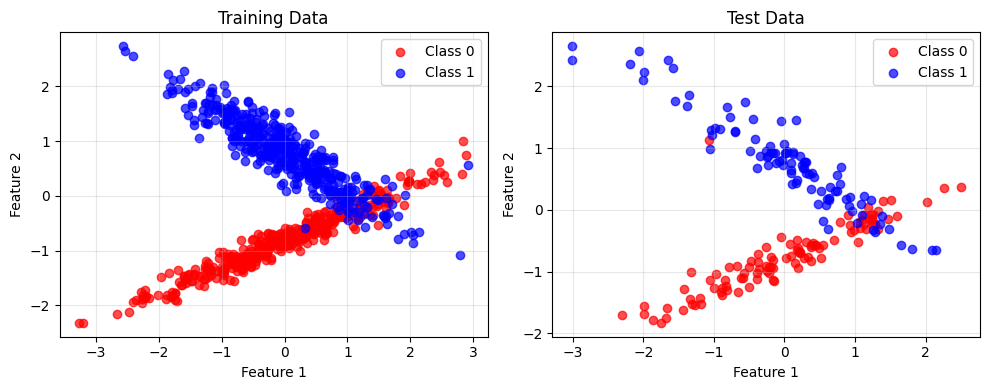

In [19]:
# Generate a synthetic binary classification dataset
def create_dataset():
    """Create a synthetic dataset for binary classification."""
    # Create a dataset with 2 features for easy visualization
    X, y = make_classification(
        n_samples=1000,
        n_features=2,
        n_redundant=0,
        n_informative=2,
        n_clusters_per_class=1,
        random_state=42
    )
    
    # Split the dataset
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    
    # Standardize features
    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_test = scaler.transform(X_test)
    
    # Reshape labels for our network
    y_train = y_train.reshape(-1, 1)
    y_test = y_test.reshape(-1, 1)
    
    return X_train, X_test, y_train, y_test, scaler

# Create the dataset
X_train, X_test, y_train, y_test, scaler = create_dataset()

print(f"Training data shape: {X_train.shape}")
print(f"Training labels shape: {y_train.shape}")
print(f"Test data shape: {X_test.shape}")
print(f"Test labels shape: {y_test.shape}")

# Visualize the dataset
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
colors = ['red', 'blue']
for i in range(2):
    mask = y_train.flatten() == i
    plt.scatter(X_train[mask, 0], X_train[mask, 1], c=colors[i], alpha=0.7, label=f'Class {i}')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('Training Data')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
for i in range(2):
    mask = y_test.flatten() == i
    plt.scatter(X_test[mask, 0], X_test[mask, 1], c=colors[i], alpha=0.7, label=f'Class {i}')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('Test Data')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Task 2.2: Train and Evaluate the Neural Network

In [20]:
# Create and train the neural network
def train_and_evaluate_network():
    """Train the neural network and evaluate its performance."""
    
    # Initialize the network
    nn = SimpleNeuralNetwork(input_size=2, hidden_size=5, output_size=1, learning_rate=0.1)
    
    print("Training Neural Network...")
    print("=" * 40)
    
    # Train the network
    try:
        nn.train(X_train, y_train, epochs=1000, verbose=True)
        
        # Make predictions
        train_predictions = nn.predict(X_train)
        test_predictions = nn.predict(X_test)
        
        # Calculate accuracies
        train_accuracy = nn.accuracy(y_train, train_predictions)
        test_accuracy = nn.accuracy(y_test, test_predictions)
        
        print(f"\nFinal Results:")
        print(f"Training Accuracy: {train_accuracy:.4f}")
        print(f"Test Accuracy: {test_accuracy:.4f}")
        
        return nn, train_predictions, test_predictions
        
    except Exception as e:
        print(f"❌ Training failed: {str(e)}")
        print("💡 Check your forward() and backward() method implementations!")
        return None, None, None

# Train the network
trained_nn, train_preds, test_preds = train_and_evaluate_network()

Training Neural Network...
Epoch 0/1000, Loss: 0.3844, Accuracy: 0.4963
Epoch 100/1000, Loss: 0.1775, Accuracy: 0.6875
Epoch 200/1000, Loss: 0.1378, Accuracy: 0.9012
Epoch 300/1000, Loss: 0.1089, Accuracy: 0.9000
Epoch 400/1000, Loss: 0.0882, Accuracy: 0.9062
Epoch 500/1000, Loss: 0.0786, Accuracy: 0.9050
Epoch 600/1000, Loss: 0.0750, Accuracy: 0.9038
Epoch 700/1000, Loss: 0.0731, Accuracy: 0.9050
Epoch 800/1000, Loss: 0.0718, Accuracy: 0.9075
Epoch 900/1000, Loss: 0.0708, Accuracy: 0.9087

Final Results:
Training Accuracy: 0.9100
Test Accuracy: 0.9050


### Task 2.3: Visualize Training Progress and Decision Boundary

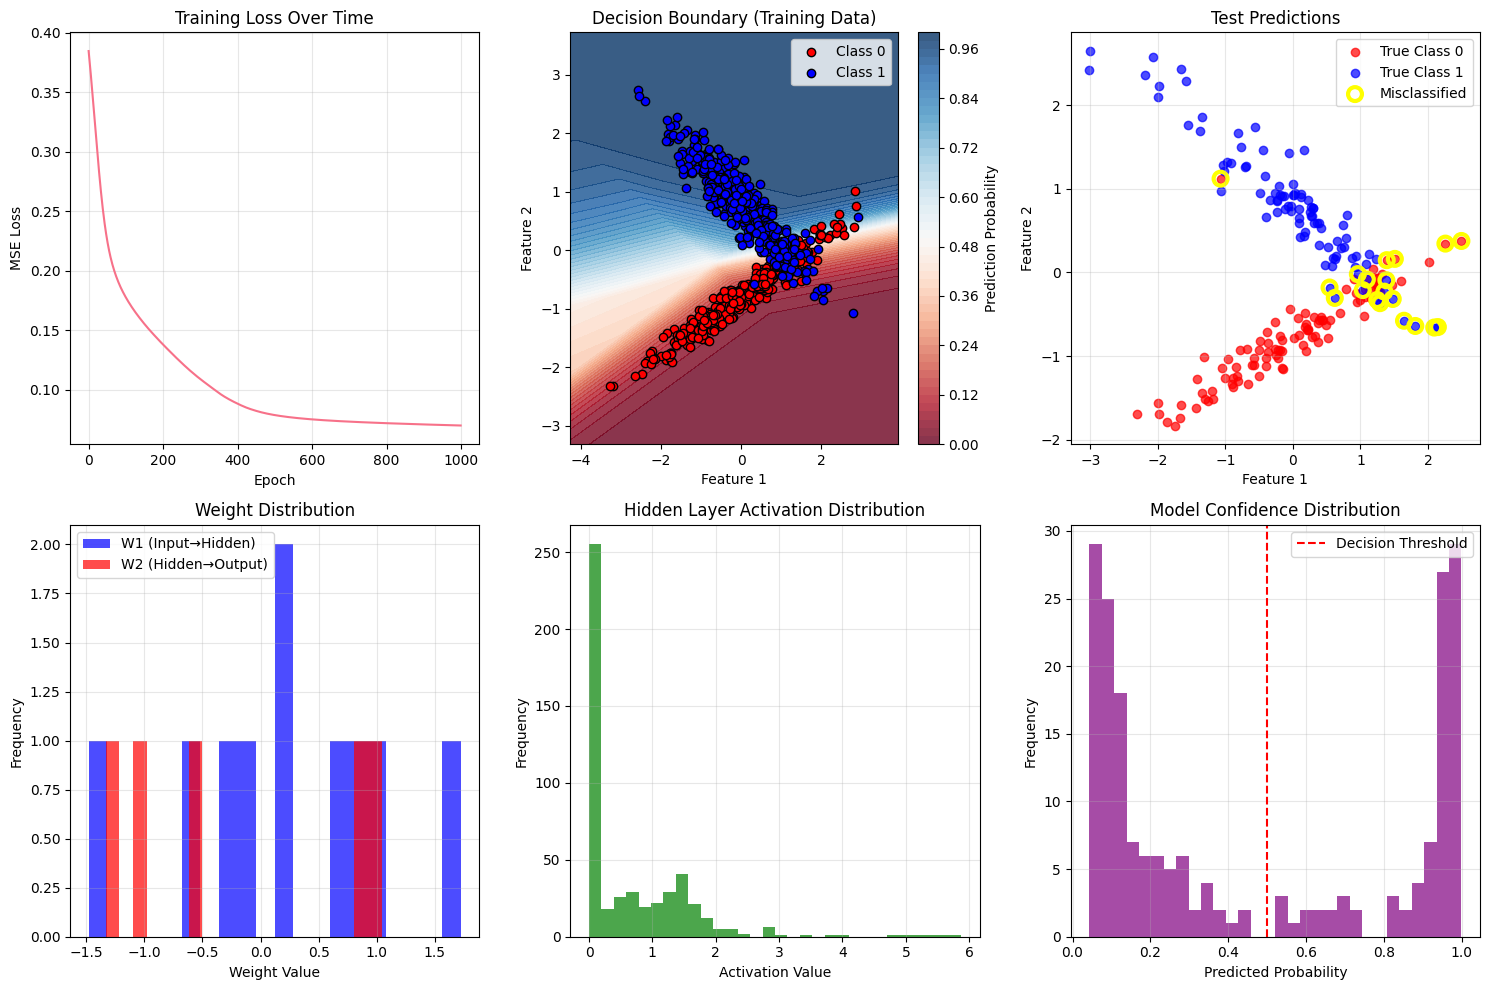

In [21]:
def visualize_training_results(nn, train_preds, test_preds):
    """Visualize training progress and decision boundary."""
    
    if nn is None:
        print("⚠️  Cannot visualize - neural network training failed.")
        print("Please implement the forward() and backward() methods first.")
        return
    
    plt.figure(figsize=(15, 10))
    
    # Plot 1: Training Loss
    plt.subplot(2, 3, 1)
    plt.plot(nn.loss_history)
    plt.xlabel('Epoch')
    plt.ylabel('MSE Loss')
    plt.title('Training Loss Over Time')
    plt.grid(True, alpha=0.3)
    
    # Plot 2: Decision Boundary
    plt.subplot(2, 3, 2)
    
    # Create a mesh to plot the decision boundary
    h = 0.02
    x_min, x_max = X_train[:, 0].min() - 1, X_train[:, 0].max() + 1
    y_min, y_max = X_train[:, 1].min() - 1, X_train[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                         np.arange(y_min, y_max, h))
    
    # Make predictions on the mesh
    mesh_points = np.c_[xx.ravel(), yy.ravel()]
    Z = nn.predict(mesh_points)
    Z = Z.reshape(xx.shape)
    
    # Plot decision boundary
    plt.contourf(xx, yy, Z, levels=50, alpha=0.8, cmap='RdBu')
    plt.colorbar(label='Prediction Probability')
    
    # Plot training points
    colors = ['red', 'blue']
    for i in range(2):
        mask = y_train.flatten() == i
        plt.scatter(X_train[mask, 0], X_train[mask, 1], c=colors[i], edgecolors='black', label=f'Class {i}')
    
    plt.xlabel('Feature 1')
    plt.ylabel('Feature 2')
    plt.title('Decision Boundary (Training Data)')
    plt.legend()
    
    # Plot 3: Test Predictions
    plt.subplot(2, 3, 3)
    
    # Plot test points with predictions
    for i in range(2):
        mask = y_test.flatten() == i
        plt.scatter(X_test[mask, 0], X_test[mask, 1], c=colors[i], alpha=0.7, label=f'True Class {i}')
    
    # Highlight misclassified points
    test_pred_classes = (test_preds > 0.5).astype(int)
    misclassified = (test_pred_classes.flatten() != y_test.flatten())
    if np.any(misclassified):
        plt.scatter(X_test[misclassified, 0], X_test[misclassified, 1], 
                   facecolors='none', edgecolors='yellow', s=100, linewidth=3, label='Misclassified')
    
    plt.xlabel('Feature 1')
    plt.ylabel('Feature 2')
    plt.title('Test Predictions')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    # Plot 4: Weight Histograms
    plt.subplot(2, 3, 4)
    plt.hist(nn.W1.flatten(), bins=20, alpha=0.7, label='W1 (Input→Hidden)', color='blue')
    plt.hist(nn.W2.flatten(), bins=20, alpha=0.7, label='W2 (Hidden→Output)', color='red')
    plt.xlabel('Weight Value')
    plt.ylabel('Frequency')
    plt.title('Weight Distribution')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    # Plot 5: Activation Distribution
    plt.subplot(2, 3, 5)
    
    # Get hidden layer activations
    sample_output = nn.forward(X_test[:100])  # Use subset for visualization
    hidden_activations = nn.cache['a1']
    
    plt.hist(hidden_activations.flatten(), bins=30, alpha=0.7, color='green')
    plt.xlabel('Activation Value')
    plt.ylabel('Frequency')
    plt.title('Hidden Layer Activation Distribution')
    plt.grid(True, alpha=0.3)
    
    # Plot 6: Prediction Confidence
    plt.subplot(2, 3, 6)
    plt.hist(test_preds.flatten(), bins=30, alpha=0.7, color='purple')
    plt.axvline(x=0.5, color='red', linestyle='--', label='Decision Threshold')
    plt.xlabel('Predicted Probability')
    plt.ylabel('Frequency')
    plt.title('Model Confidence Distribution')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

# Visualize results
visualize_training_results(trained_nn, train_preds, test_preds)

### Reflection Question 2.1
**Answer the following questions:**

1. How does the loss decrease during training? Is the convergence smooth or erratic?
2. Looking at the decision boundary, how well does your neural network separate the two classes?
3. What do you observe about the weight distributions after training?
4. How confident is your model in its predictions (based on the prediction confidence plot)?

**Your Answer:**
1. The loss decreases quickly at first and then gradually levels off. Convergence is smooth with no large oscillations.

2. The decision boundary separates the two classes well in most areas. Misclassified points are concentrated in the overlapping margin region.

3. Weights are centered near zero with a moderate spread and no extreme outliers. Many hidden units produce near zero activations because of the ReLU, resulting in a distribution with a strong mass near zero and a smaller positive tail.

4. Predicted probabilities are mostly close to zero or one, so the model is generally confident. A few misclassified points are predicted with high confidence, which suggests calibration could improve reliability.

---
## ✅ Part 2 Checklist: Neural Network Implementation

**Before proceeding to Part 3, make sure you have completed all the following tasks:**

### Forward Propagation Tasks:
- [ ] **TODO 2.1**: Implemented `z1 = X @ W1 + b1` (linear transformation for hidden layer)
- [ ] **TODO 2.2**: Implemented `a1 = relu(z1)` (ReLU activation for hidden layer)
- [ ] **TODO 2.3**: Implemented `z2 = a1 @ W2 + b2` (linear transformation for output layer)
- [ ] **TODO 2.4**: Implemented `a2 = sigmoid(z2)` (sigmoid activation for output layer)
- [ ] **Verification**: `forward()` method returns predictions without errors

### Backward Propagation Tasks:
- [ ] **TODO 2.5**: Implemented `dz2 = (output - y) * sigmoid_derivative(z2)` (output layer gradients)
- [ ] **TODO 2.6**: Implemented `dW2 = (1/m) * a1.T @ dz2` (weights gradient for output layer)
- [ ] **TODO 2.7**: Implemented `db2 = (1/m) * np.sum(dz2, axis=0, keepdims=True)` (bias gradient for output layer)
- [ ] **TODO 2.8**: Implemented `da1 = dz2 @ W2.T` (hidden layer activation gradients)
- [ ] **TODO 2.9**: Implemented `dz1 = da1 * relu_derivative(z1)` (hidden layer pre-activation gradients)
- [ ] **TODO 2.10**: Implemented `dW1 = (1/m) * X.T @ dz1` (weights gradient for hidden layer)
- [ ] **TODO 2.11**: Implemented `db1 = (1/m) * np.sum(dz1, axis=0, keepdims=True)` (bias gradient for hidden layer)

### Gradient Descent Updates:
- [ ] **TODO 2.12**: Implemented `self.W2 -= self.learning_rate * dW2`
- [ ] **TODO 2.13**: Implemented `self.b2 -= self.learning_rate * db2`
- [ ] **TODO 2.14**: Implemented `self.W1 -= self.learning_rate * dW1`
- [ ] **TODO 2.15**: Implemented `self.b1 -= self.learning_rate * db1`

### Verification Tasks:
- [ ] **Training Success**: `train_and_evaluate_network()` completes without "❌ Training failed" message
- [ ] **Loss Decrease**: Training loss decreases over epochs (visible in loss history plot)
- [ ] **Reasonable Accuracy**: Training and test accuracy > 0.7 (for this dataset)
- [ ] **Visualizations Work**: All 6 plots display correctly (loss, decision boundary, predictions, weights, activations, confidence)

### Understanding Tasks:
- [ ] **Reflection 2.1**: Answered all four questions about loss convergence, decision boundary, weights, and model confidence
- [ ] **Concept Check**: Can explain the difference between forward and backward propagation
- [ ] **Concept Check**: Understand how gradient descent updates the weights

### Troubleshooting:
- **If training fails**: Check that all TODO implementations return actual values (not `None`)
- **If loss doesn't decrease**: Verify gradient calculations and ensure learning rate isn't too high/low
- **If accuracy is low**: Check activation functions and gradient flow through the network
- **If visualizations fail**: Ensure forward propagation works and caches intermediate values

**🎯 Goal**: Neural network should train successfully with decreasing loss and reasonable classification accuracy.

---

---
# Part 3: Hyperparameter Exploration

Experiment with different hyperparameters to understand their impact on training.

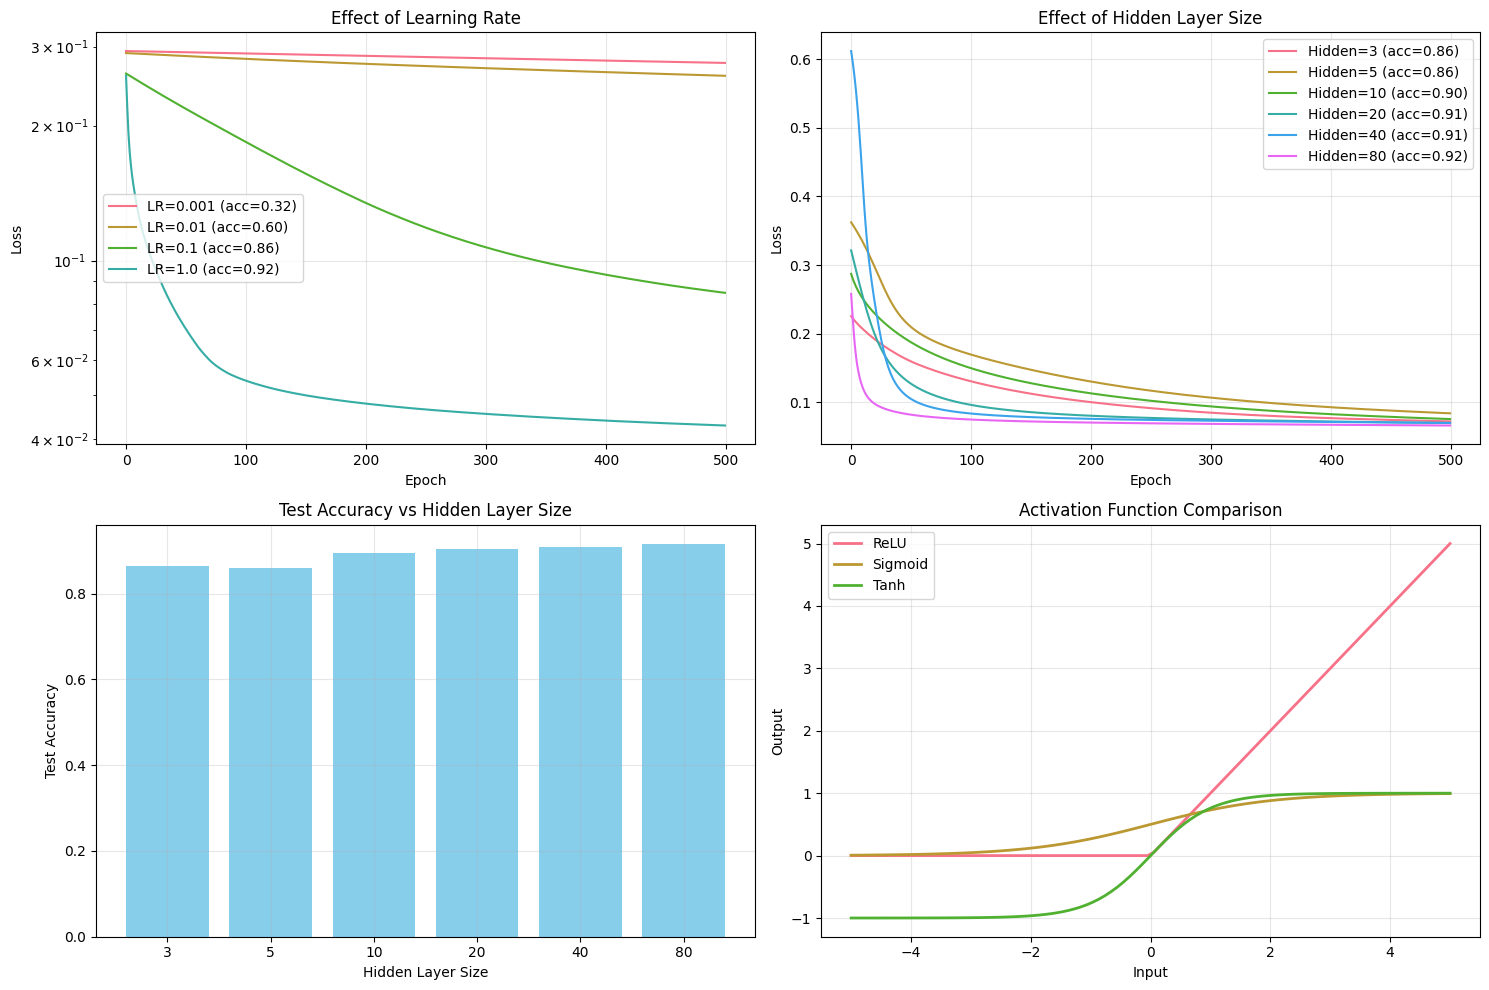


Hyperparameter Experiment Summary:
Learning Rate Results:
  LR=0.001: Final Test Acc=0.3200, LossHistoryLen=500
  LR=0.01: Final Test Acc=0.6050, LossHistoryLen=500
  LR=0.1: Final Test Acc=0.8600, LossHistoryLen=500
  LR=1.0: Final Test Acc=0.9150, LossHistoryLen=500

Hidden Layer Results:
  Hidden=3: Test Acc=0.8650
  Hidden=5: Test Acc=0.8600
  Hidden=10: Test Acc=0.8950
  Hidden=20: Test Acc=0.9050
  Hidden=40: Test Acc=0.9100
  Hidden=80: Test Acc=0.9150


In [25]:
def experiment_with_hyperparameters(run_bonus=False, epochs=500):
    """Run hyperparameter experiments for learning rates and hidden sizes."""
    learning_rates = [0.001, 0.01, 0.1, 1.0]
    plt.figure(figsize=(15, 10))
    
    # --- Learning rate comparison ---
    plt.subplot(2, 2, 1)
    lr_results = []
    for lr in learning_rates:
        nn = SimpleNeuralNetwork(input_size=2, hidden_size=5, output_size=1, learning_rate=lr)
        try:
            nn.train(X_train, y_train, epochs=epochs, verbose=False)
            test_acc = nn.accuracy(y_test, nn.predict(X_test))
            lr_results.append((lr, nn.loss_history, test_acc))
            plt.plot(nn.loss_history, label=f'LR={lr} (acc={test_acc:.2f})')
        except Exception as e:
            print(f"Training failed for LR = {lr}: {e}")
            lr_results.append((lr, [], 0.0))
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title('Effect of Learning Rate')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.yscale('log')
    
    # Optional: run an extended set of learning rates for bonus analysis
    if run_bonus:
        ext_lrs = [0.0001, 0.0005, 0.005, 0.05, 0.5]
        for lr in ext_lrs:
            nn = SimpleNeuralNetwork(input_size=2, hidden_size=5, output_size=1, learning_rate=lr)
            try:
                nn.train(X_train, y_train, epochs=epochs, verbose=False)
                test_acc = nn.accuracy(y_test, nn.predict(X_test))
                plt.plot(nn.loss_history, linestyle='--', label=f'LR={lr} (acc={test_acc:.2f})')
            except Exception as e:
                print(f"Bonus training failed for LR = {lr}: {e}")
    
    # --- Hidden layer size comparison ---
    hidden_sizes = [3, 5, 10, 20, 40, 80]
    plt.subplot(2, 2, 2)
    final_accuracies = []
    for hidden_size in hidden_sizes:
        nn = SimpleNeuralNetwork(input_size=2, hidden_size=hidden_size, output_size=1, learning_rate=0.1)
        try:
            nn.train(X_train, y_train, epochs=epochs, verbose=False)
            test_preds = nn.predict(X_test)
            accuracy = nn.accuracy(y_test, test_preds)
            final_accuracies.append(accuracy)
            plt.plot(nn.loss_history, label=f'Hidden={hidden_size} (acc={accuracy:.2f})')
        except Exception as e:
            print(f"Training failed for hidden size = {hidden_size}: {e}")
            final_accuracies.append(0.0)
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title('Effect of Hidden Layer Size')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    # --- Accuracy comparison bar chart ---
    plt.subplot(2, 2, 3)
    plt.bar([str(hs) for hs in hidden_sizes], final_accuracies, color='skyblue')
    plt.xlabel('Hidden Layer Size')
    plt.ylabel('Test Accuracy')
    plt.title('Test Accuracy vs Hidden Layer Size')
    plt.grid(True, alpha=0.3)
    
    # --- Activation function shapes (informational) ---
    plt.subplot(2, 2, 4)
    x = np.linspace(-5, 5, 100)
    relu_y = np.maximum(0, x)
    sigmoid_y = 1 / (1 + np.exp(-x))
    tanh_y = np.tanh(x)
    plt.plot(x, relu_y, label='ReLU', linewidth=2)
    plt.plot(x, sigmoid_y, label='Sigmoid', linewidth=2)
    plt.plot(x, tanh_y, label='Tanh', linewidth=2)
    plt.xlabel('Input')
    plt.ylabel('Output')
    plt.title('Activation Function Comparison')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # --- Summary outputs ---
    print("\nHyperparameter Experiment Summary:")
    print("=" * 40)
    print("Learning Rate Results:")
    for lr, hist, acc in lr_results:
        print(f"  LR={lr}: Final Test Acc={acc:.4f}, LossHistoryLen={len(hist)}")
    print("\nHidden Layer Results:")
    for hs, acc in zip(hidden_sizes, final_accuracies):
        print(f"  Hidden={hs}: Test Acc={acc:.4f}")

# Run hyperparameter experiments (set run_bonus=True to run extended tests)
experiment_with_hyperparameters()

### Reflection Question 3.1
**Answer the following questions:**

1. What happens when the learning rate is too high or too low?
2. How does increasing the hidden layer size affect training and final accuracy?
3. Which activation functions seem most suitable for different parts of the network and why?
4. What trade-offs do you observe between model complexity and performance?

**Your Answer:**
1. A learning rate that is too low makes training very slow and may prevent the model from reaching good accuracy. A learning rate that is too high makes training unstable and can cause the loss to oscillate or diverge. Tune the learning rate to the largest value that still produces steady loss decrease.

2. Increasing the hidden layer size raises the model capacity and usually improves accuracy up to a point. After that the gains become small and the model requires more compute and is more likely to overfit without more data or regularization.

3. ReLU is the preferred activation for hidden layers because it gives sparse activations and reliable gradients. Tanh can be useful when zero centered activations help. Sigmoid is appropriate for a single output probability in binary classification.

4. Greater model complexity increases representational power but also increases computation, memory, tuning effort, and overfitting risk. Prefer the smallest model that meets performance requirements and scale complexity only after tuning learning rate and regularization.

---
## ✅ Part 3 Checklist: Hyperparameter Exploration

**Make sure you have completed all the following tasks:**

### Hyperparameter Experiments:
- [ ] **Learning Rate Analysis**: Successfully ran experiments with different learning rates [0.001, 0.01, 0.1, 1.0]
- [ ] **Architecture Analysis**: Successfully ran experiments with different hidden layer sizes [3, 5, 10, 20]
- [ ] **Verification**: All learning rate experiments show different convergence patterns
- [ ] **Verification**: Different hidden layer sizes show varying final accuracies
- [ ] **Verification**: All 4 plots display correctly (learning rates, hidden sizes, accuracy comparison, activation functions)

### Analysis and Understanding:
- [ ] **Reflection 3.1**: Answered all four questions about learning rate effects, hidden layer size impact, activation functions, and complexity trade-offs
- [ ] **Observation**: Can identify which learning rates converge too slowly, too quickly, or optimally
- [ ] **Observation**: Can explain the relationship between model complexity and performance
- [ ] **Comparison**: Understand the differences between ReLU, Sigmoid, and Tanh activation functions

### Optional Enhancements (Bonus):
- [ ] **Custom Experiments**: Tried different learning rate ranges or hidden layer sizes
- [ ] **Additional Analysis**: Explored other hyperparameters (epochs, initialization methods, etc.)
- [ ] **Advanced Visualizations**: Added custom plots or analysis beyond the basic requirements

### Final Verification:
- [ ] **All Plots Working**: Hyperparameter experiment plots display without errors
- [ ] **Performance Summary**: Can explain which hyperparameter settings work best and why
- [ ] **Concept Mastery**: Understand the impact of hyperparameters on neural network training

### Troubleshooting:
- **If training fails for some hyperparameters**: This is expected behavior - document which ones fail and why
- **If plots are empty**: Check that the experiments actually ran and stored results
- **If accuracies are all similar**: Try wider ranges of hyperparameters to see more dramatic differences

**🎯 Goal**: Successfully explore the impact of different hyperparameters on neural network performance and understand the trade-offs involved.

---